# Lab Task 4: Top Hat

## Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load Image

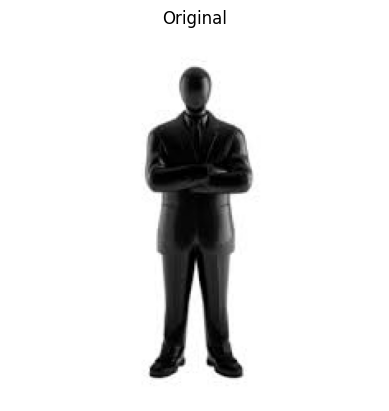

In [2]:
img = cv2.imread('../CVLab01/assets/image.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off'); plt.show()

## Top Hat Operation

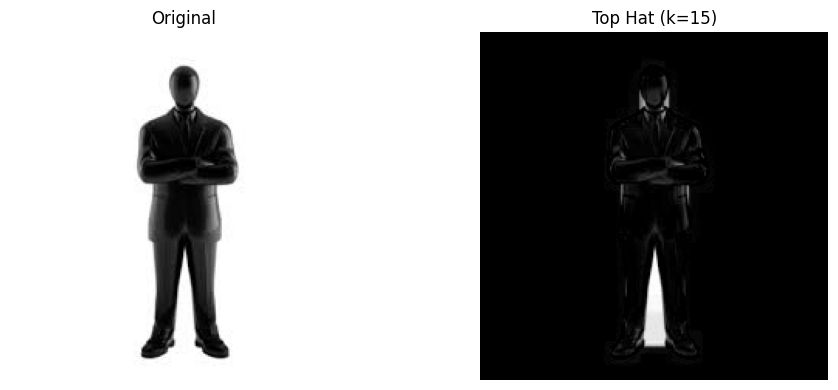

In [3]:
# Top Hat = Original - Opening
# Reveals small bright details/features that are brighter than surroundings

kernel   = np.ones((15, 15), np.uint8)
tophat   = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img,    cmap='gray'); axes[0].set_title('Original');        axes[0].axis('off')
axes[1].imshow(tophat, cmap='gray'); axes[1].set_title('Top Hat (k=15)');  axes[1].axis('off')
plt.tight_layout(); plt.show()

## Kernel Size Comparison

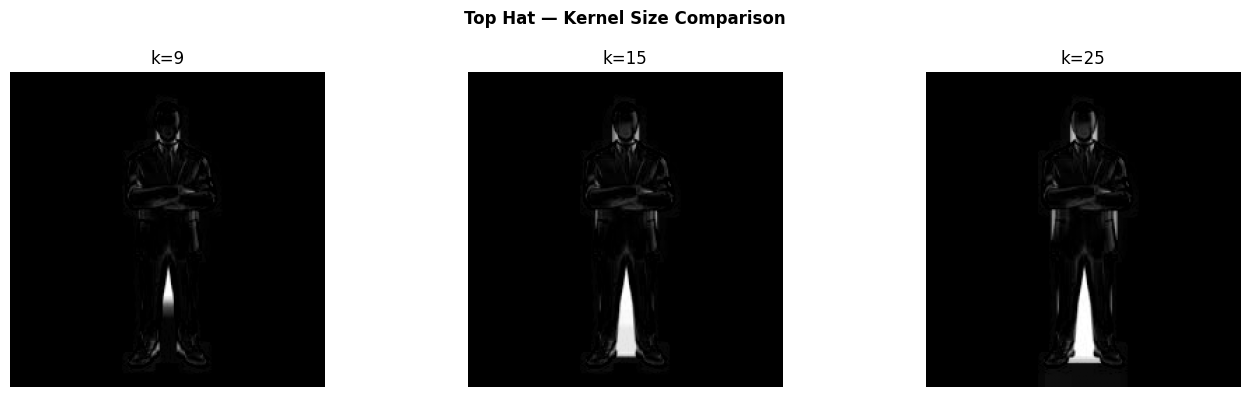

In [4]:
sizes = [9, 15, 25]
hats  = [cv2.morphologyEx(img, cv2.MORPH_TOPHAT, np.ones((k, k), np.uint8)) for k in sizes]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Top Hat — Kernel Size Comparison', fontweight='bold')
for ax, res, k in zip(axes, hats, sizes):
    ax.imshow(res, cmap='gray'); ax.set_title(f'k={k}'); ax.axis('off')
plt.tight_layout(); plt.show()

## Enhanced Brightness using Top Hat

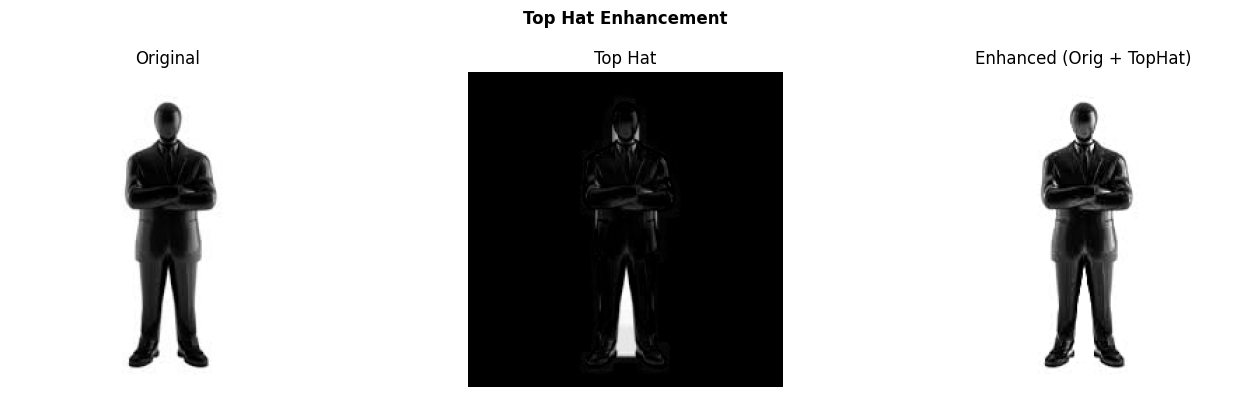

Top Hat = Original - Opening
Extracts small bright features/details smaller than the kernel size
Larger kernel = captures larger bright regions
Common use: illumination correction, detecting bright spots on dark background


In [5]:
# Adding top hat result back to original enhances bright details
enhanced = cv2.add(img, tophat)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Top Hat Enhancement', fontweight='bold')
for ax, im, lbl in zip(axes, [img, tophat, enhanced], ['Original', 'Top Hat', 'Enhanced (Orig + TopHat)']):
    ax.imshow(im, cmap='gray'); ax.set_title(lbl); ax.axis('off')
plt.tight_layout(); plt.show()

print('Top Hat = Original - Opening')
print('Extracts small bright features/details smaller than the kernel size')
print('Larger kernel = captures larger bright regions')
print('Common use: illumination correction, detecting bright spots on dark background')